In [17]:
from langchain_openai import ChatOpenAI
from pprint import pprint
from typing import TypedDict, Literal, Annotated
import random
from IPython.display import Image, display
from langgraph.graph import StateGraph, END, START, MessagesState
from langgraph.graph.message import add_messages

from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, AnyMessage

model = ChatOpenAI(model_name="gpt-5-nano")

# pprint(model.invoke("Hello, how are you?"))


In [4]:

messages = [
  AIMessage(content="So you said you were researching AI agents?", name="Model")
]

messages.extend([HumanMessage(content="Yes, I'm interested in learning more about AI agents.", name="User")])
messages.extend([AIMessage(content="Great! What specifically would you like to know?", name="Model")])
messages.extend([HumanMessage(content="Can you tell me more about the different types of AI agents?", name="User")])

for m in messages:
  m.pretty_print()


================================== Ai Message ==================================
Name: Model

So you said you were researching AI agents?
================================ Human Message =================================
Name: User

Yes, I'm interested in learning more about AI agents.
================================== Ai Message ==================================
Name: Model

Great! What specifically would you like to know?
================================ Human Message =================================
Name: User

Can you tell me more about the different types of AI agents?


In [5]:
result = model.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [7]:
# result
result.response_metadata

{'token_usage': {'completion_tokens': 2353,
  'prompt_tokens': 73,
  'total_tokens': 2426,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 1344,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-5-nano-2025-08-07',
 'system_fingerprint': None,
 'id': 'chatcmpl-DHXaDR6tfjD53u8ZPMUtbDI7BwPwA',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

In [8]:

def multiply(a: int, b: int) -> int:
  """
  Multiply two numbers together and return the result.
  
  Args:
    a: The first number.
    b: The second number.
  
  Returns:
    The product of a and b.
  """
  return a * b

model_with_tools = model.bind_tools([multiply])

In [11]:
tool_call = model_with_tools.invoke([HumanMessage(content="What is 23 multiplied by 45?", name="user")])
print(tool_call)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 218, 'prompt_tokens': 149, 'total_tokens': 367, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DHXdxoPzpm9SfgfqLEbSjub1F3SD9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019cd367-1039-7282-8a39-af225f2213bd-0' tool_calls=[{'name': 'multiply', 'args': {'a': 23, 'b': 45}, 'id': 'call_9UgfP4JdbGTW3ZJPn1EQ8k7z', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 149, 'output_tokens': 218, 'total_tokens': 367, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 192}}


In [18]:
class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

In [19]:
# Reducers sample

initial_messages = [
  HumanMessage(content="Hello, how are you?"),
  AIMessage(content="I'm good, thanks! How about you?"),
  HumanMessage(content="I'm doing well too!")
]

print(add_messages(initial_messages, [HumanMessage(content="Hi!")]))

[HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='155aced9-727a-4685-b3fa-45bf9ead4483'), AIMessage(content="I'm good, thanks! How about you?", additional_kwargs={}, response_metadata={}, id='b36d2360-cfcd-4019-abbf-d9987309bb61', tool_calls=[], invalid_tool_calls=[]), HumanMessage(content="I'm doing well too!", additional_kwargs={}, response_metadata={}, id='c2c4b74b-fe4a-4fc4-b382-ea5267f4581e'), HumanMessage(content='Hi!', additional_kwargs={}, response_metadata={}, id='2377b43e-7de1-40ac-9213-ab79d688005c')]


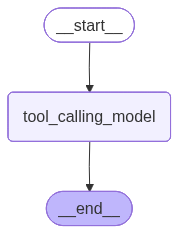

In [22]:
## Graph

class MessagesState(MessagesState):
  # Add any additional fields here
  # Don't remove messages field, it's required for the state
  pass

# Node
def tool_calling_model(state: MessagesState):
  return {"messages": [model_with_tools.invoke(state["messages"])]}

# Graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_model", tool_calling_model)

builder.add_edge(START, "tool_calling_model")
builder.add_edge("tool_calling_model", END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))


In [23]:
# Invoke 
messages = [HumanMessage(content="Hello, how are you?")]
result = graph.invoke({"messages": messages})
print(result)

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='394ca812-d2f1-4636-b9b1-cafbb69ac854'), AIMessage(content='Hello! I’m here and ready to help with whatever you need. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 222, 'prompt_tokens': 145, 'total_tokens': 367, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DHXlgxCDZeXnG0PCiCfgXE39KbYJ4', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019cd36e-5c04-71a1-a3a6-24003639c152-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 145, 'output_tokens': 222, 'total_tokens': 367, 'input_token_

In [24]:
messages = [HumanMessage(content="Multiply 2 and 3")]
result = graph.invoke({"messages": messages})
print(result)

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='5d94240a-7778-48c8-879e-d70329560e75'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 218, 'prompt_tokens': 145, 'total_tokens': 363, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DHXmC2A59XAsvOilpXdunuKL7ZRLu', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019cd36e-dcdf-7c21-a74f-012429172400-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': 'call_A7OvU1YXFYVv0q5menajfF3O', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 145, 'output_tokens': 218, 'total_tok

In [ ]:
# handle results 
